## **Music clustering project**

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("ML_spotify_data.csv")

In [4]:
df.head()

,name,artists,popularity,danceability,valence,energy,explicit,key,liveness,loudness,speechiness,tempo
0,We're For The Dark - Remastered 2010,['Badfinger'],22,0.678,0.559,0.432,0,3,0.0727,-12.696,0.0334,117.674
1,Sixty Years On - Piano Demo,['Elton John'],25,0.456,0.259,0.368,0,6,0.1560,-10.692,0.0280,143.783
2,Got to Find Another Way,['The Guess Who'],21,0.433,0.833,0.724,0,0,0.1700,-9.803,0.0378,84.341
3,Feelin' Alright - Live At The Fillmore East/1970,['Joe Cocker'],22,0.436,0.870,0.914,0,5,0.8550,-6.955,0.0610,174.005
4,Caravan - Take 7,['Van Morrison'],23,0.669,0.564,0.412,0,7,0.4010,-13.095,0.0679,78.716


**Goal: Gain insights into different music styles and potentially enhance recommendation systems**

In [5]:
print(df.columns)

Index(['name', 'artists', 'popularity', 'danceability', 'valence', 'energy',
       'explicit', 'key', 'liveness', 'loudness', 'speechiness', 'tempo'],
      dtype='str')


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          10000 non-null  str    
 1   artists       10000 non-null  str    
 2   popularity    10000 non-null  int64  
 3   danceability  10000 non-null  float64
 4   valence       10000 non-null  float64
 5   energy        10000 non-null  float64
 6   explicit      10000 non-null  int64  
 7   key           10000 non-null  int64  
 8   liveness      10000 non-null  float64
 9   loudness      10000 non-null  float64
 10  speechiness   10000 non-null  float64
 11  tempo         10000 non-null  float64
dtypes: float64(7), int64(3), str(2)
memory usage: 937.6 KB


In [7]:
df.isnull().sum()

name            0
artists         0
popularity      0
danceability    0
valence         0
energy          0
explicit        0
key             0
liveness        0
loudness        0
speechiness     0
tempo           0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(1)

Drop duplicates

In [9]:
df = df.drop_duplicates()

print(df.shape)

(9999, 12)


## EDA

In [10]:
df.describe()

,popularity,danceability,valence,energy,explicit,key,liveness,loudness,speechiness,tempo
count,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000
mean,37.558056,0.549502,0.523128,0.592592,0.103210,5.205921,0.209719,-9.822424,0.081431,120.179381
std,12.559743,0.178105,0.261461,0.251815,0.304249,3.562083,0.193584,5.321321,0.100476,30.262242
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-60.000000,0.000000,0.000000
25%,27.000000,0.430000,0.313000,0.414000,0.000000,2.000000,0.093900,-12.348500,0.034200,96.190500
50%,36.000000,0.557000,0.524000,0.616000,0.000000,5.000000,0.129000,-8.761000,0.045100,118.328000
75%,46.000000,0.681000,0.742000,0.801000,0.000000,9.000000,0.261000,-6.070500,0.077400,139.612000
max,86.000000,0.986000,0.996000,1.000000,1.000000,11.000000,1.000000,1.073000,0.957000,224.437000


Identify audio features that will be used for clustering

In [11]:
df.dtypes

name                str
artists             str
popularity        int64
danceability    float64
valence         float64
energy          float64
explicit          int64
key               int64
liveness        float64
loudness        float64
speechiness     float64
tempo           float64
dtype: object

In [12]:
audio_features = [
    "danceability",
    "valence",
    "energy",
    "liveness",
    "loudness",
    "speechiness",
    "tempo"
]

In [13]:
X = df[audio_features].copy()

X.head()

,danceability,valence,energy,liveness,loudness,speechiness,tempo
0,0.678,0.559,0.432,0.0727,-12.696,0.0334,117.674
1,0.456,0.259,0.368,0.1560,-10.692,0.0280,143.783
2,0.433,0.833,0.724,0.1700,-9.803,0.0378,84.341
3,0.436,0.870,0.914,0.8550,-6.955,0.0610,174.005
4,0.669,0.564,0.412,0.4010,-13.095,0.0679,78.716


In [14]:
X.dtypes

danceability    float64
valence         float64
energy          float64
liveness        float64
loudness        float64
speechiness     float64
tempo           float64
dtype: object

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [16]:
X_scaled = pd.DataFrame(
    X_scaled,
    columns=audio_features
)

X_scaled.head()

,danceability,valence,energy,liveness,loudness,speechiness,tempo
0,0.721506,0.137205,-0.637769,-0.707836,-0.540039,-0.478059,-0.082793
1,-0.525009,-1.010251,-0.891936,-0.277511,-0.163422,-0.531806,0.780008
2,-0.654152,1.185215,0.521868,-0.205187,0.003650,-0.434265,-1.184320
3,-0.637307,1.326734,1.276427,3.333499,0.538883,-0.203353,1.778728
4,0.670972,0.156329,-0.717197,0.988150,-0.615024,-0.134676,-1.370204


In [17]:
X_scaled.shape

(9999, 7)

## PCA: for visualization

In [18]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("PCA shape:", X_pca.shape)

Original shape: (9999, 7)
PCA shape: (9999, 7)


How much variation does each PC explain?

In [19]:
explained_variance = pca.explained_variance_ratio_

for i, variance in enumerate(explained_variance, start=1):
    print(f"PC{i}: {variance:.4f}")

PC1: 0.3243
PC2: 0.1951
PC3: 0.1579
PC4: 0.1215
PC5: 0.1116
PC6: 0.0606
PC7: 0.0290


Cumulative explained variance

In [20]:
cumulative_variance = explained_variance.cumsum()

for i, variance in enumerate(cumulative_variance, start=1):
    print(f"PC{i}: {variance:.4f}")

PC1: 0.3243
PC2: 0.5194
PC3: 0.6773
PC4: 0.7988
PC5: 0.9104
PC6: 0.9710
PC7: 1.0000


Plot cumulative explained variance

How many principal components do I need to retain most of the information in my original 7 features?

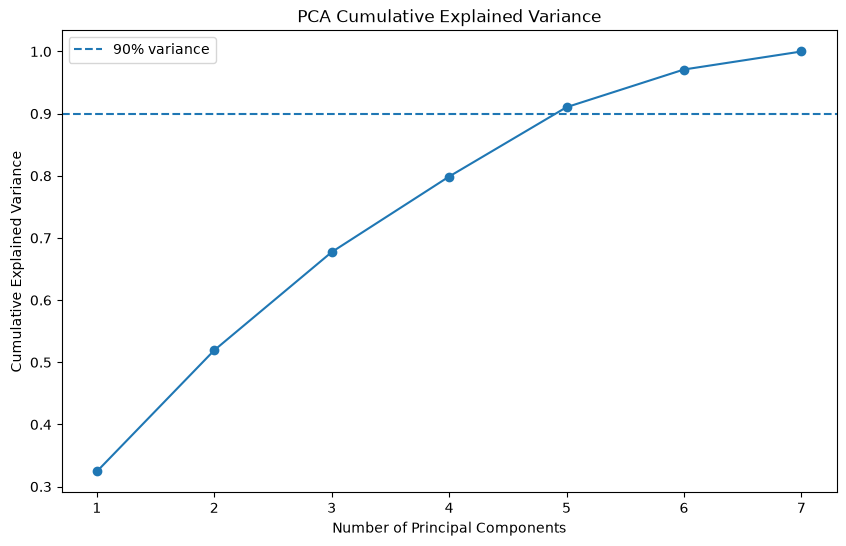

In [21]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")

plt.axhline(
    y=0.90,
    linestyle="--",
    label="90% variance"
)

plt.legend()
plt.show()

Create the 2D PCA representation

In [22]:
pca_2 = PCA(n_components=2)

X_pca_2 = pca_2.fit_transform(X_scaled)

print(X_pca_2.shape)

(9999, 2)


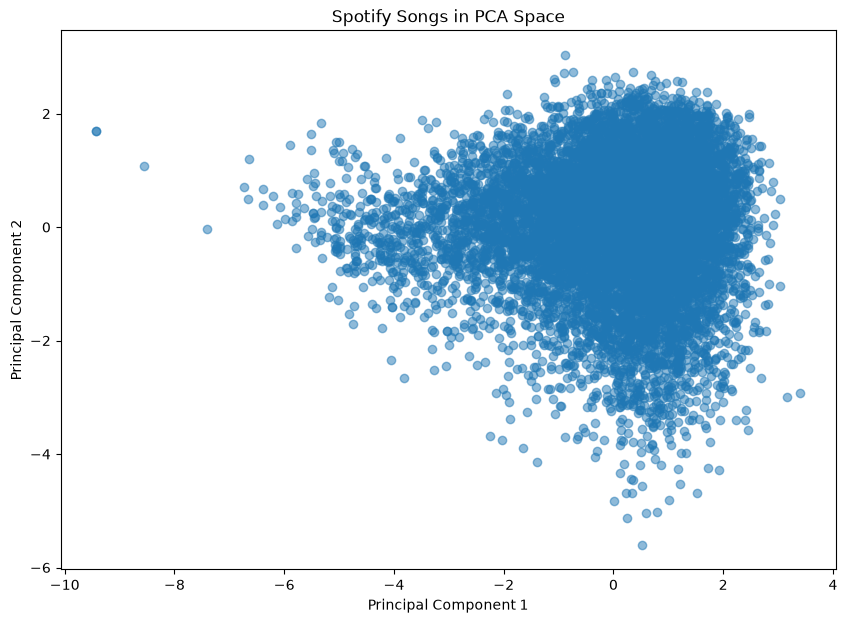

In [23]:
plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca_2[:, 0],
    X_pca_2[:, 1],
    alpha=0.5
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Spotify Songs in PCA Space")

plt.show()

See which features contribute to each PC

In [24]:
pca_components = pd.DataFrame(
    pca.components_,
    columns=audio_features,
    index=[
        f"PC{i}"
        for i in range(1, len(audio_features) + 1)
    ]
)

pca_components

,danceability,valence,energy,liveness,loudness,speechiness,tempo
PC1,0.360054,0.435707,0.547138,0.103453,0.545602,0.193015,0.188469
PC2,0.590845,0.391414,-0.286298,-0.509330,-0.172564,-0.073553,-0.348031
PC3,0.175084,-0.086943,-0.079956,0.456369,-0.133608,0.702912,-0.484959
PC4,0.078196,0.092636,-0.246771,-0.178269,-0.283516,0.529117,0.729576
PC5,0.105560,0.495574,-0.189526,0.662691,-0.327335,-0.366925,0.162487
PC6,0.620284,-0.570802,-0.276839,0.222461,0.276733,-0.198085,0.217911
PC7,0.297657,-0.263450,0.662438,-0.034332,-0.624963,-0.097022,0.044723


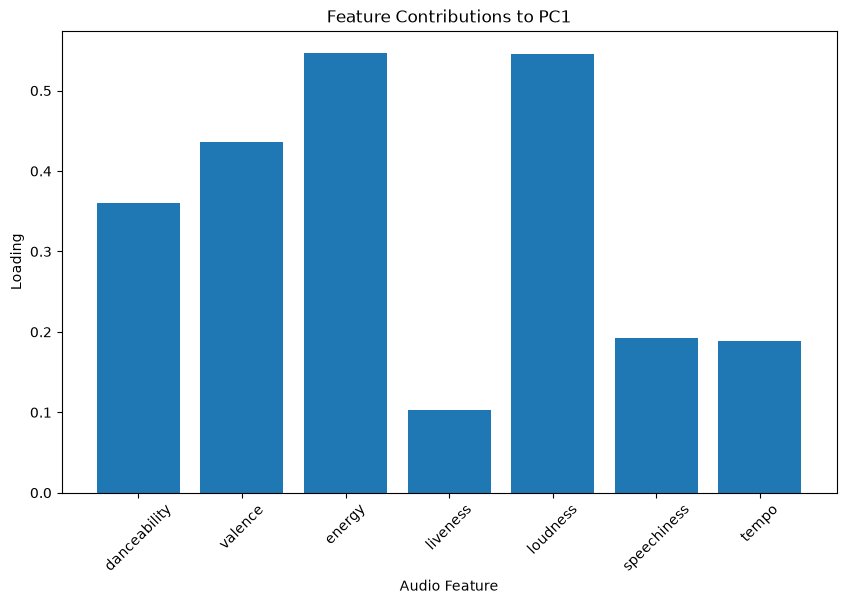

In [25]:
plt.figure(figsize=(10, 6))

plt.bar(
    audio_features,
    pca.components_[0]
)

plt.xlabel("Audio Feature")
plt.ylabel("Loading")
plt.title("Feature Contributions to PC1")

plt.xticks(rotation=45)

plt.show()

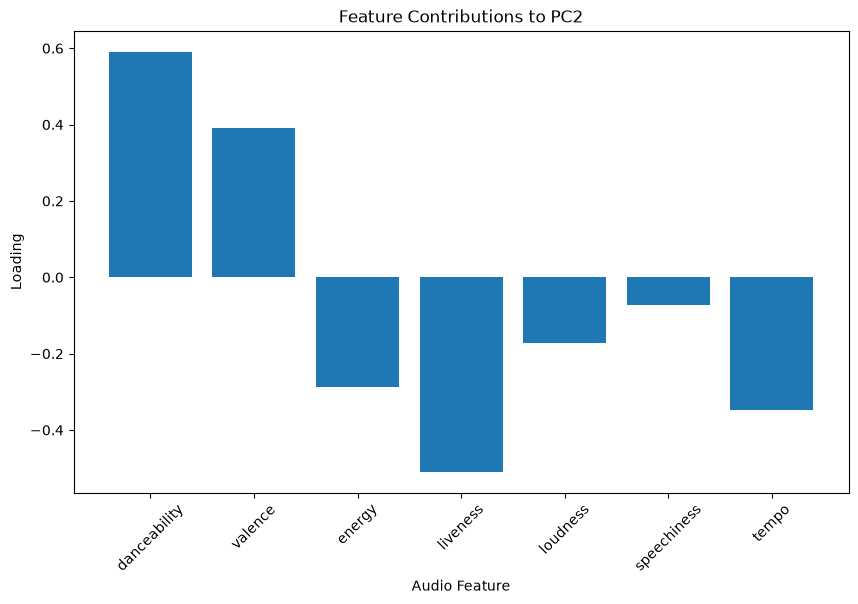

In [26]:
plt.figure(figsize=(10, 6))

plt.bar(
    audio_features,
    pca.components_[1]
)

plt.xlabel("Audio Feature")
plt.ylabel("Loading")
plt.title("Feature Contributions to PC2")

plt.xticks(rotation=45)

plt.show()

## K-Means

In [27]:
from sklearn.cluster import KMeans

inertia = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    
    inertia.append(kmeans.inertia_)

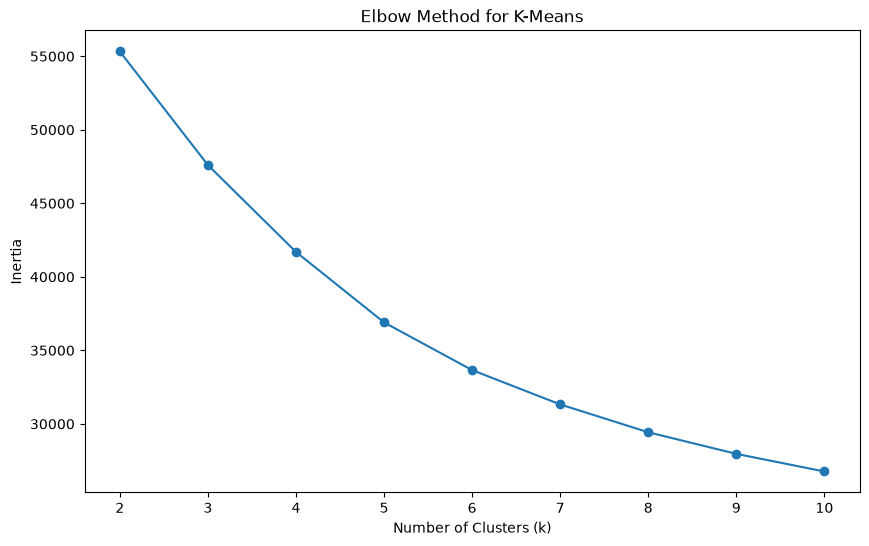

In [28]:
plt.figure(figsize=(10, 6))

plt.plot(
    K,
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")

plt.show()

**There is not a very obvious elbow.**

Calculate silhouette scores

In [29]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(
        X_scaled,
        labels
    )
    
    silhouette_scores.append(score)

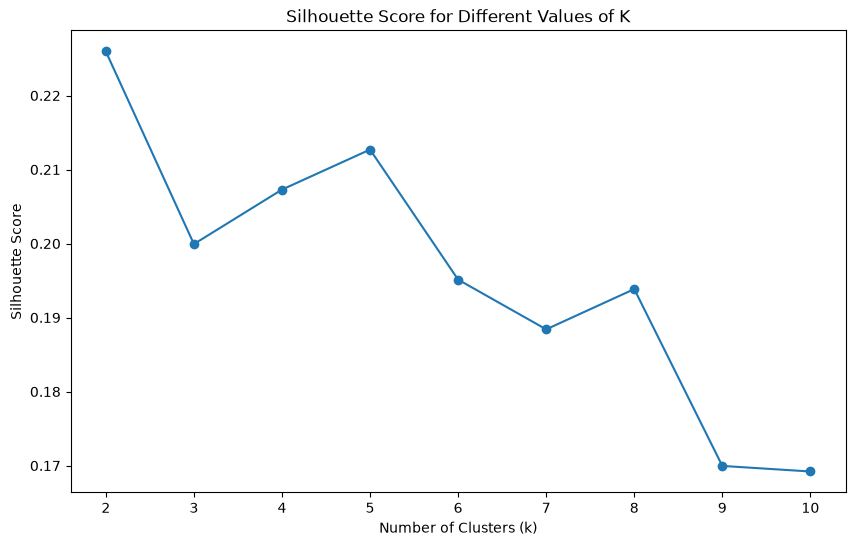

In [30]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different Values of K")

plt.show()

In [31]:
for k, score in zip(range(2, 11), silhouette_scores):
    print(f"k={k}: {score:.4f}")

k=2: 0.2259
k=3: 0.1999
k=4: 0.2073
k=5: 0.2127
k=6: 0.1951
k=7: 0.1884
k=8: 0.1938
k=9: 0.1700
k=10: 0.1692


Using k=2 for first model (based on silhouette score):

In [32]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

df["KMeans_Cluster"] = kmeans_labels

In [33]:
df["KMeans_Cluster"].value_counts().sort_index()

KMeans_Cluster
0    7181
1    2818
Name: count, dtype: int64

Then visualize the two clusters using PCA

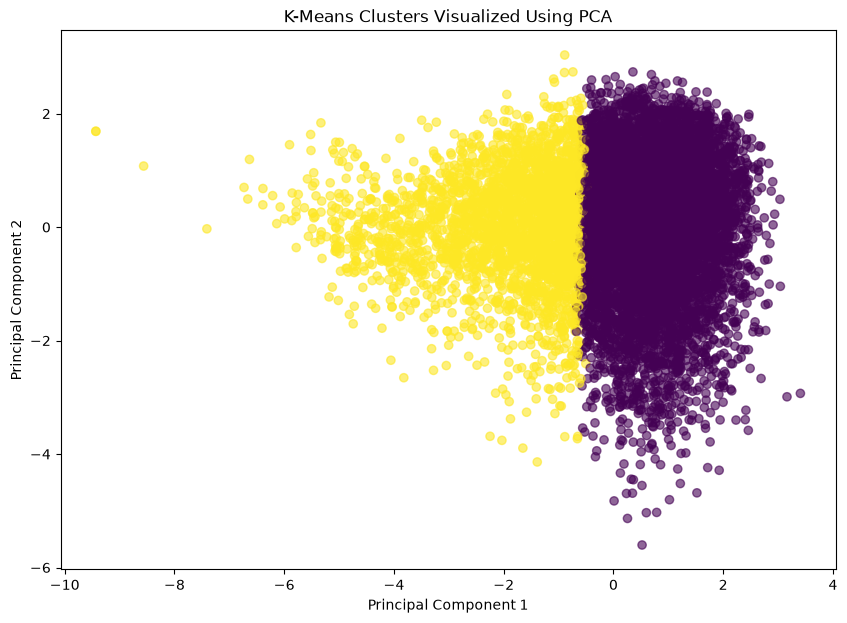

In [34]:
plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca_2[:, 0],
    X_pca_2[:, 1],
    c=kmeans_labels,
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters Visualized Using PCA")

plt.show()

Profile the clusters

In [35]:
cluster_profile = df.groupby("KMeans_Cluster")[audio_features].mean()

cluster_profile

,danceability,valence,energy,liveness,loudness,speechiness,tempo
KMeans_Cluster,,,,,,,
0,0.594166,0.610865,0.707606,0.222600,-7.753805,0.094496,124.358865
1,0.435687,0.299552,0.299506,0.176896,-15.093805,0.048139,109.528966


In [36]:
df["KMeans_Cluster"].value_counts().sort_index()

KMeans_Cluster
0    7181
1    2818
Name: count, dtype: int64

## Hierarchical Clustering

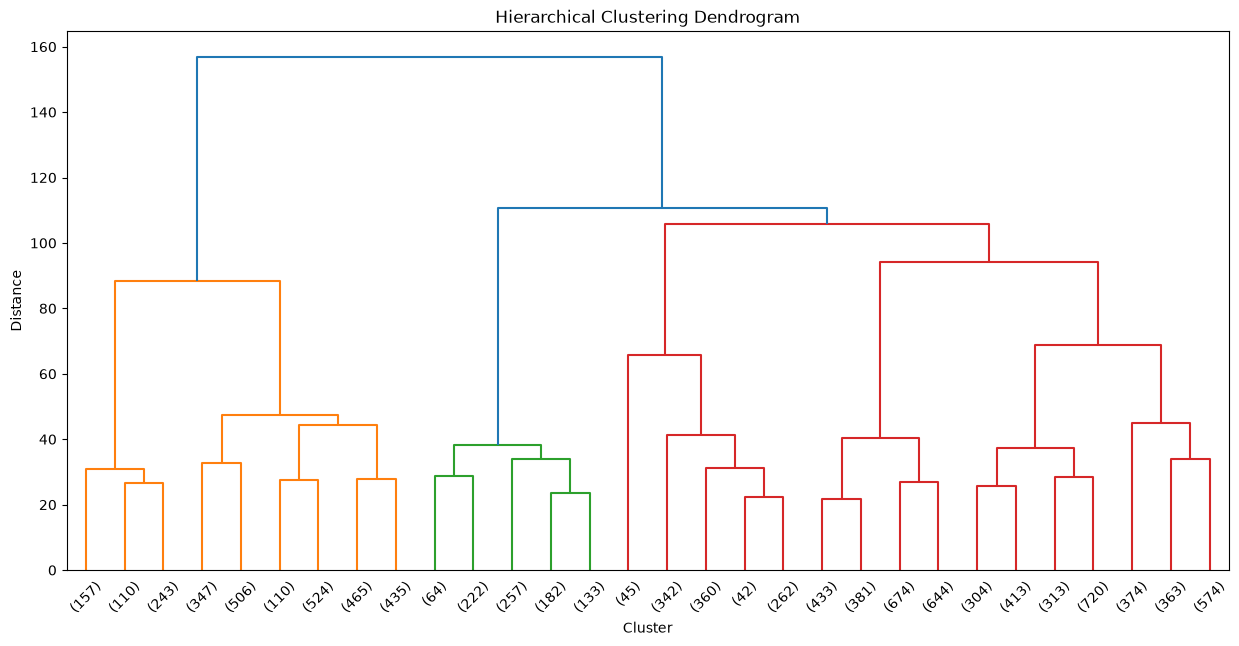

In [37]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(15, 7))

dendrogram(
    Z,
    truncate_mode="lastp",
    p=30
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Cluster")
plt.ylabel("Distance")

plt.show()

**The observations in the left cluster have characteristics that are substantially different from the observations in the other clusters, while the middle and right groups are comparatively more similar to each other.**

3 hierarchical clusters

In [38]:
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

hierarchical_labels = hierarchical.fit_predict(X_scaled)

df["Hierarchical_Cluster"] = hierarchical_labels

In [39]:
df["Hierarchical_Cluster"].value_counts().sort_index()

Hierarchical_Cluster
0    6244
1    2897
2     858
Name: count, dtype: int64

In [40]:
from sklearn.metrics import silhouette_score

hierarchical_silhouette = silhouette_score(
    X_scaled,
    hierarchical_labels
)

print("Hierarchical Clustering Silhouette Score:",
      hierarchical_silhouette)

Hierarchical Clustering Silhouette Score: 0.18959027875396608


**K-Means 2-cluster solution has a higher silhouette score than the 3-cluster**

**Both scores are fairly low. This suggests the Spotify songs don't naturally divide into very sharply separated groups based on the seven audio features we're using.**

## DBSCAN

DBSCAN uses:

- -1 = noise/outliers

- 0, 1, 2, 3, 4, 5 = clusters

In [41]:
from sklearn.cluster import DBSCAN
import numpy as np

dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

unique_labels, counts = np.unique(
    dbscan_labels,
    return_counts=True
)

dict(zip(unique_labels, counts))

{np.int64(-1): np.int64(6858),
 np.int64(0): np.int64(2748),
 np.int64(1): np.int64(5),
 np.int64(2): np.int64(6),
 np.int64(3): np.int64(15),
 np.int64(4): np.int64(26),
 np.int64(5): np.int64(12),
 np.int64(6): np.int64(5),
 np.int64(7): np.int64(4),
 np.int64(8): np.int64(5),
 np.int64(9): np.int64(10),
 np.int64(10): np.int64(4),
 np.int64(11): np.int64(4),
 np.int64(12): np.int64(13),
 np.int64(13): np.int64(6),
 np.int64(14): np.int64(4),
 np.int64(15): np.int64(6),
 np.int64(16): np.int64(5),
 np.int64(17): np.int64(8),
 np.int64(18): np.int64(6),
 np.int64(19): np.int64(11),
 np.int64(20): np.int64(2),
 np.int64(21): np.int64(5),
 np.int64(22): np.int64(5),
 np.int64(23): np.int64(12),
 np.int64(24): np.int64(12),
 np.int64(25): np.int64(4),
 np.int64(26): np.int64(10),
 np.int64(27): np.int64(5),
 np.int64(28): np.int64(5),
 np.int64(29): np.int64(4),
 np.int64(30): np.int64(9),
 np.int64(31): np.int64(5),
 np.int64(32): np.int64(7),
 np.int64(33): np.int64(1),
 np.int64(34): 

**DBSCAN with eps=0.5 is not giving us a useful clustering structure.**

**The most important numbers are:**

**Noise (-1): 6,858 songs → 68.6%**

**Cluster 0: 2,748 songs → 27.5%**

**The remaining clusters are tiny, mostly only 2–26 songs each**

**So DBSCAN is treating most of the songs as noise. That's too much to be useful for this project.**

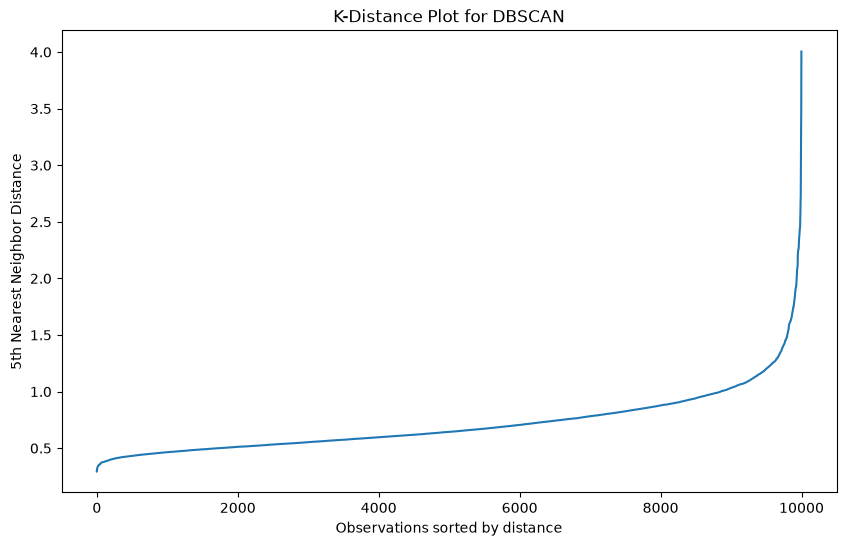

In [42]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

neighbors = NearestNeighbors(n_neighbors=5)
neighbors.fit(X_scaled)

distances, indices = neighbors.kneighbors(X_scaled)

k_distances = np.sort(distances[:, 4])

plt.figure(figsize=(10, 6))
plt.plot(k_distances)

plt.xlabel("Observations sorted by distance")
plt.ylabel("5th Nearest Neighbor Distance")
plt.title("K-Distance Plot for DBSCAN")
plt.show()

**From your plot, the bend appears to be around 1.2–1.4, approximately 1.3.**

**Increasing eps to around 1.3 should allow DBSCAN to find more neighboring songs and reduce the excessive amount of noise.**

In [43]:
from sklearn.cluster import DBSCAN
import numpy as np

dbscan = DBSCAN(
    eps=1.3,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

unique_labels, counts = np.unique(
    dbscan_labels,
    return_counts=True
)

dict(zip(unique_labels, counts))

{np.int64(-1): np.int64(200),
 np.int64(0): np.int64(9793),
 np.int64(1): np.int64(6)}

**eps=1.3 is probably too large for this dataset.**

**At eps=1.3, almost everything has been connected into one giant cluster.**

Let's test eps=0.8

In [44]:
dbscan = DBSCAN(
    eps=0.8,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

unique_labels, counts = np.unique(
    dbscan_labels,
    return_counts=True
)

dict(zip(unique_labels, counts))

{np.int64(-1): np.int64(1776),
 np.int64(0): np.int64(8015),
 np.int64(1): np.int64(14),
 np.int64(2): np.int64(5),
 np.int64(3): np.int64(54),
 np.int64(4): np.int64(4),
 np.int64(5): np.int64(15),
 np.int64(6): np.int64(5),
 np.int64(7): np.int64(5),
 np.int64(8): np.int64(5),
 np.int64(9): np.int64(8),
 np.int64(10): np.int64(5),
 np.int64(11): np.int64(7),
 np.int64(12): np.int64(5),
 np.int64(13): np.int64(4),
 np.int64(14): np.int64(13),
 np.int64(15): np.int64(5),
 np.int64(16): np.int64(7),
 np.int64(17): np.int64(11),
 np.int64(18): np.int64(5),
 np.int64(19): np.int64(5),
 np.int64(20): np.int64(10),
 np.int64(21): np.int64(3),
 np.int64(22): np.int64(9),
 np.int64(23): np.int64(4)}

**At eps=0.8, DBSCAN is still producing one overwhelmingly large cluster.**

At eps=0.7

In [45]:
dbscan = DBSCAN(
    eps=0.7,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

unique_labels, counts = np.unique(
    dbscan_labels,
    return_counts=True
)

dict(zip(unique_labels, counts))

{np.int64(-1): np.int64(2865),
 np.int64(0): np.int64(6930),
 np.int64(1): np.int64(5),
 np.int64(2): np.int64(5),
 np.int64(3): np.int64(6),
 np.int64(4): np.int64(3),
 np.int64(5): np.int64(8),
 np.int64(6): np.int64(5),
 np.int64(7): np.int64(6),
 np.int64(8): np.int64(5),
 np.int64(9): np.int64(12),
 np.int64(10): np.int64(10),
 np.int64(11): np.int64(9),
 np.int64(12): np.int64(3),
 np.int64(13): np.int64(39),
 np.int64(14): np.int64(4),
 np.int64(15): np.int64(6),
 np.int64(16): np.int64(3),
 np.int64(17): np.int64(6),
 np.int64(18): np.int64(5),
 np.int64(19): np.int64(4),
 np.int64(20): np.int64(5),
 np.int64(21): np.int64(5),
 np.int64(22): np.int64(7),
 np.int64(23): np.int64(3),
 np.int64(24): np.int64(5),
 np.int64(25): np.int64(4),
 np.int64(26): np.int64(5),
 np.int64(27): np.int64(3),
 np.int64(28): np.int64(4),
 np.int64(29): np.int64(4),
 np.int64(30): np.int64(5),
 np.int64(31): np.int64(5),
 np.int64(32): np.int64(5)}

In [46]:
dbscan = DBSCAN(
    eps=0.7,
    min_samples=10
)

dbscan_labels = dbscan.fit_predict(X_scaled)

unique_labels, counts = np.unique(
    dbscan_labels,
    return_counts=True
)

dict(zip(unique_labels, counts))

{np.int64(-1): np.int64(3900),
 np.int64(0): np.int64(6047),
 np.int64(1): np.int64(17),
 np.int64(2): np.int64(9),
 np.int64(3): np.int64(8),
 np.int64(4): np.int64(10),
 np.int64(5): np.int64(8)}

In [47]:
eps_values = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1]

for eps in eps_values:
    dbscan = DBSCAN(
        eps=eps,
        min_samples=10
    )

    labels = dbscan.fit_predict(X_scaled)

    unique_labels, counts = np.unique(labels, return_counts=True)

    print(f"\neps = {eps}")
    print(dict(zip(unique_labels, counts)))


eps = 0.5
{np.int64(-1): np.int64(8802), np.int64(0): np.int64(79), np.int64(1): np.int64(669), np.int64(2): np.int64(43), np.int64(3): np.int64(11), np.int64(4): np.int64(33), np.int64(5): np.int64(10), np.int64(6): np.int64(32), np.int64(7): np.int64(38), np.int64(8): np.int64(19), np.int64(9): np.int64(14), np.int64(10): np.int64(9), np.int64(11): np.int64(111), np.int64(12): np.int64(6), np.int64(13): np.int64(11), np.int64(14): np.int64(37), np.int64(15): np.int64(13), np.int64(16): np.int64(5), np.int64(17): np.int64(12), np.int64(18): np.int64(36), np.int64(19): np.int64(9)}

eps = 0.6
{np.int64(-1): np.int64(5978), np.int64(0): np.int64(3905), np.int64(1): np.int64(11), np.int64(2): np.int64(5), np.int64(3): np.int64(27), np.int64(4): np.int64(12), np.int64(5): np.int64(9), np.int64(6): np.int64(9), np.int64(7): np.int64(5), np.int64(8): np.int64(15), np.int64(9): np.int64(7), np.int64(10): np.int64(6), np.int64(11): np.int64(10)}

eps = 0.7
{np.int64(-1): np.int64(3900), np.i

Calculate the distance to each point's 10th nearest neighbor. The point where the distances start rising sharply can help us select a more informed eps rather than testing arbitrary values.

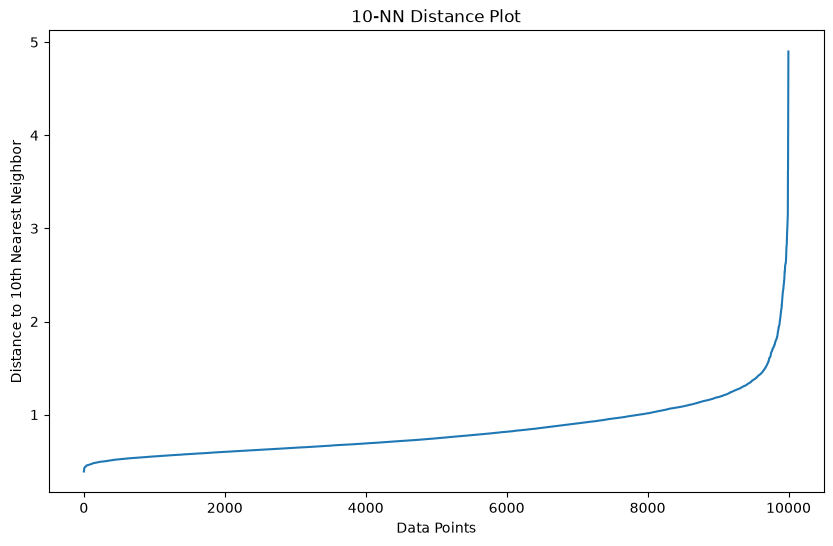

In [48]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

neighbors = NearestNeighbors(n_neighbors=10)
neighbors.fit(X_scaled)

distances, indices = neighbors.kneighbors(X_scaled)

# Distance to the 10th nearest neighbor
k_distances = distances[:, 9]

# Sort distances
k_distances = np.sort(k_distances)

plt.figure(figsize=(10, 6))
plt.plot(k_distances)
plt.xlabel("Data Points")
plt.ylabel("Distance to 10th Nearest Neighbor")
plt.title("10-NN Distance Plot")
plt.show()

In [49]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np

results = []

eps_values = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5]
min_samples_values = [5, 10, 15, 20, 25]

for eps in eps_values:
    for min_samples in min_samples_values:

        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = dbscan.fit_predict(X_scaled)

        # Number of clusters, excluding noise (-1)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        # Percentage of observations classified as noise
        noise_percentage = np.mean(labels == -1) * 100

        # Silhouette only if there are at least 2 clusters
        non_noise = labels != -1

        if n_clusters >= 2 and np.sum(non_noise) > n_clusters:
            silhouette = silhouette_score(
                X_scaled[non_noise],
                labels[non_noise]
            )
        else:
            silhouette = np.nan

        results.append([
            eps,
            min_samples,
            n_clusters,
            noise_percentage,
            silhouette
        ])

results_df = pd.DataFrame(
    results,
    columns=[
        'eps',
        'min_samples',
        'clusters',
        'noise_percentage',
        'silhouette'
    ]
)

results_df.sort_values(
    by='silhouette',
    ascending=False
).head(15)

,eps,min_samples,clusters,noise_percentage,silhouette
3,0.5,20,2,99.399940,0.809476
35,1.2,5,2,2.570257,0.653056
40,1.3,5,2,2.000200,0.650793
45,1.4,5,3,1.600160,0.642546
2,0.5,15,7,97.339734,0.504612
28,1.0,20,2,16.301630,0.368255
34,1.1,25,2,12.011201,0.355188
33,1.1,20,2,10.201020,0.352346
12,0.7,15,2,46.034603,0.344985
50,1.5,5,5,1.090109,0.300566


In [50]:
from sklearn.cluster import DBSCAN
import pandas as pd

dbscan = DBSCAN(eps=1.2, min_samples=5)

labels = dbscan.fit_predict(X_scaled)

cluster_counts = pd.Series(labels).value_counts().sort_index()

print(cluster_counts)

-1     257
 0    9737
 1       5
Name: count, dtype: int64


In [51]:
for eps in [1.2, 1.3, 1.4]:

    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_scaled)

    print(f"\nEPS = {eps}")
    print(pd.Series(labels).value_counts().sort_index())


EPS = 1.2
-1     257
 0    9737
 1       5
Name: count, dtype: int64

EPS = 1.3
-1     200
 0    9793
 1       6
Name: count, dtype: int64

EPS = 1.4
-1     160
 0    9827
 1       6
 2       6
Name: count, dtype: int64


**DBSCAN is not too suitable for this project**

# GMM

Test different numbers of clusters

In [52]:
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

n_components = range(2, 11)

aic_scores = []
bic_scores = []

for k in n_components:
    gmm = GaussianMixture(
        n_components=k,
        random_state=42
    )
    
    gmm.fit(X_scaled)
    
    aic_scores.append(gmm.aic(X_scaled))
    bic_scores.append(gmm.bic(X_scaled))

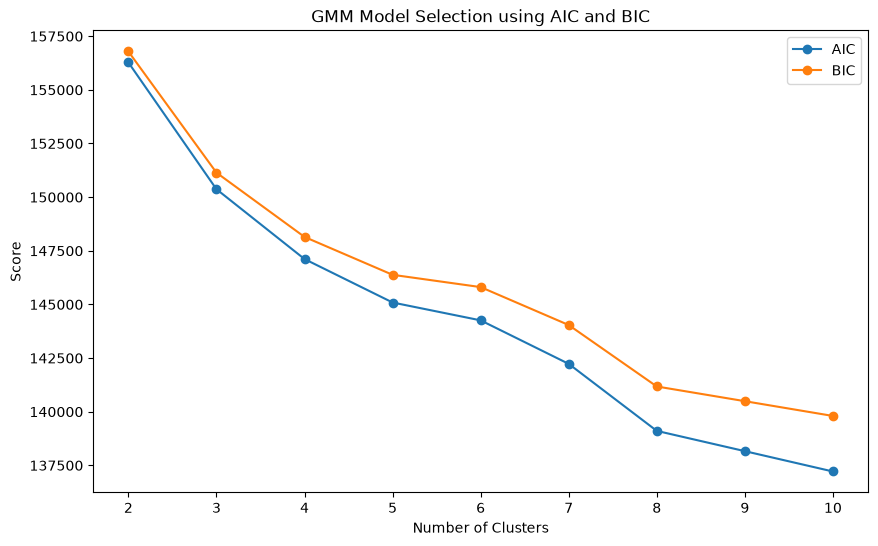

In [53]:
plt.figure(figsize=(10, 6))

plt.plot(n_components, aic_scores, marker='o', label='AIC')
plt.plot(n_components, bic_scores, marker='o', label='BIC')

plt.xlabel("Number of Clusters")
plt.ylabel("Score")
plt.title("GMM Model Selection using AIC and BIC")
plt.xticks(n_components)
plt.legend()
plt.show()

In [54]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in n_components:
    gmm = GaussianMixture(
        n_components=k,
        random_state=42
    )
    
    labels = gmm.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    
    print(f"K = {k}, Silhouette Score = {score:.3f}")

K = 2, Silhouette Score = 0.129
K = 3, Silhouette Score = 0.073
K = 4, Silhouette Score = 0.045
K = 5, Silhouette Score = 0.062
K = 6, Silhouette Score = 0.059
K = 7, Silhouette Score = 0.055
K = 8, Silhouette Score = 0.011
K = 9, Silhouette Score = 0.031
K = 10, Silhouette Score = -0.006


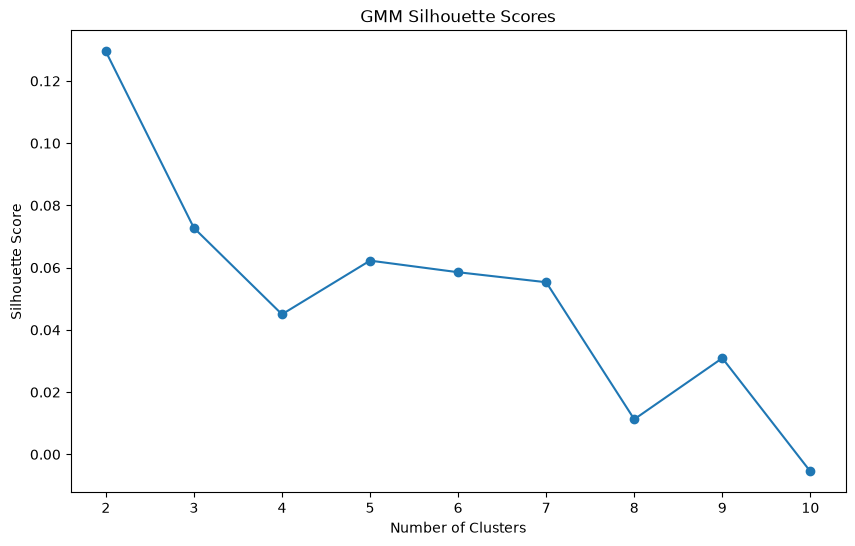

In [56]:
plt.figure(figsize=(10, 6))

plt.plot(
    n_components,
    silhouette_scores,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("GMM Silhouette Scores")
plt.xticks(n_components)
plt.show()

In [57]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    gmm = GaussianMixture(
        n_components=k,
        random_state=42
    )
    
    labels = gmm.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    
    print(f"K = {k}, Silhouette Score = {score:.3f}")

K = 2, Silhouette Score = 0.129
K = 3, Silhouette Score = 0.073
K = 4, Silhouette Score = 0.045
K = 5, Silhouette Score = 0.062
K = 6, Silhouette Score = 0.059
K = 7, Silhouette Score = 0.055
K = 8, Silhouette Score = 0.011
K = 9, Silhouette Score = 0.031
K = 10, Silhouette Score = -0.006


**K = 2 has the highest silhouette score, but 0.129 is still quite low.**

**So although 2 is the best among the tested values, it does not indicate strongly separated clusters.**

In [58]:
gmm = GaussianMixture(
    n_components=5,
    random_state=42
)

labels = gmm.fit_predict(X_scaled)

print(pd.Series(labels).value_counts().sort_index())

0    1807
1    2242
2    3421
3    1413
4    1116
Name: count, dtype: int64


**This is a much healthier cluster distribution.**

Investigating K=2

In [59]:
from sklearn.mixture import GaussianMixture
import pandas as pd

gmm_2 = GaussianMixture(
    n_components=2,
    random_state=42,
    n_init=10
)

gmm_labels = gmm_2.fit_predict(X_scaled)

print("Cluster sizes:")
print(pd.Series(gmm_labels).value_counts().sort_index())

Cluster sizes:
0    6543
1    3456
Name: count, dtype: int64


In [60]:
probabilities = gmm_2.predict_proba(X_scaled)

print(probabilities[:10])

[[9.93960395e-001 6.03960493e-003]
 [9.97564719e-001 2.43528098e-003]
 [9.92260896e-001 7.73910360e-003]
 [5.14366212e-016 1.00000000e+000]
 [9.26273153e-003 9.90737268e-001]
 [9.99180327e-001 8.19672706e-004]
 [9.98326898e-001 1.67310207e-003]
 [9.85046643e-001 1.49533570e-002]
 [9.91037550e-001 8.96244995e-003]
 [4.63372362e-198 1.00000000e+000]]


In [61]:
max_prob = probabilities.max(axis=1)

print("Average membership probability:",
      max_prob.mean())

print("Minimum membership probability:",
      max_prob.min())

Average membership probability: 0.9578721692918474
Minimum membership probability: 0.500077523305557


**The average maximum probability is 95.8%, meaning that, on average, GMM is quite confident about which of the two components an observation belongs to.**

Profile the two clusters

In [62]:
# Add cluster labels to your original dataframe
df_gmm = df.copy()
df_gmm['GMM_Cluster'] = gmm_labels

# Compare the means of each variable by cluster
cluster_profile = df_gmm.groupby('GMM_Cluster').mean(numeric_only=True)

print(cluster_profile)

             popularity  danceability   valence    energy  explicit       key  \
GMM_Cluster                                                                     
0             36.611952      0.535418  0.515680  0.531550  0.031026  5.158643   
1             39.349248      0.576166  0.537229  0.708158  0.239873  5.295428   

             liveness   loudness  speechiness       tempo  KMeans_Cluster  \
GMM_Cluster                                                                 
0            0.142339 -10.800871     0.040902  118.424394        0.377044   
1            0.337285  -7.970000     0.158161  123.501974        0.101562   

             Hierarchical_Cluster  
GMM_Cluster                        
0                        0.420602  
1                        0.538484  


**The GMM analysis identified two broad groups of songs with relatively balanced cluster sizes (65.4% and 34.6%). Cluster 1 was characterized by higher energy, danceability, loudness, liveness, speechiness and explicit-content levels, while Cluster 0 consisted of comparatively lower-energy and less explicit tracks. However, the low silhouette score (0.129) indicates substantial overlap between the two groups, suggesting that the dataset does not contain strongly separated musical clusters.**

Valiation and Visualization

In [63]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(
    n_components=2,
    random_state=42,
    n_init=10
)

gmm_labels = gmm.fit_predict(X_scaled)

df['GMM_Cluster'] = gmm_labels

Visualize the GMM clusters using PCA

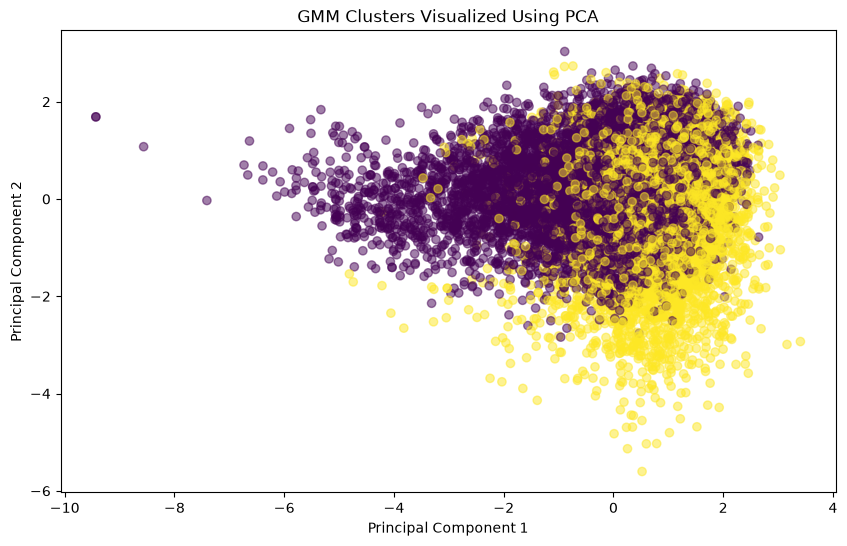

In [64]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=gmm_labels,
    alpha=0.5
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("GMM Clusters Visualized Using PCA")

plt.show()

how much variation PCA captures

In [65]:
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("Total explained variance:",
      pca.explained_variance_ratio_.sum())

Explained variance ratio:
[0.3243296  0.19505183]
Total explained variance: 0.5193814310563292


**53% of the total variation**

Compare the two clusters properly

In [66]:
features = [
    'popularity',
    'danceability',
    'valence',
    'energy',
    'explicit',
    'key',
    'liveness',
    'loudness',
    'speechiness',
    'tempo'
]

cluster_profile = df.groupby('GMM_Cluster')[features].mean()

print(cluster_profile)

             popularity  danceability   valence    energy  explicit       key  \
GMM_Cluster                                                                     
0             36.611952      0.535418  0.515680  0.531550  0.031026  5.158643   
1             39.349248      0.576166  0.537229  0.708158  0.239873  5.295428   

             liveness   loudness  speechiness       tempo  
GMM_Cluster                                                
0            0.142339 -10.800871     0.040902  118.424394  
1            0.337285  -7.970000     0.158161  123.501974  


In [67]:
probabilities = gmm.predict_proba(X_scaled)

confidence = probabilities.max(axis=1)

print("High confidence (>90%):",
      (confidence > 0.90).sum())

print("Moderate confidence (70–90%):",
      ((confidence >= 0.70) & (confidence <= 0.90)).sum())

print("Low confidence (<70%):",
      (confidence < 0.70).sum())

High confidence (>90%): 8785
Moderate confidence (70–90%): 767
Low confidence (<70%): 447


**The GMM analysis identified two broad musical groups differentiated primarily by energy, danceability, loudness, liveness, speechiness, and explicit content. Cluster 0 consisted mainly of lower-energy and less explicit songs, while Cluster 1 contained songs with higher energy and stronger danceability, loudness, liveness, speechiness, and explicit-content characteristics. The model assigned 87.9% of songs to a cluster with over 90% membership confidence. However, the low silhouette score (0.129) suggests substantial overlap between the groups, indicating that the dataset does not contain strongly distinct musical clusters. Overall, GMM is useful for identifying broad patterns in the music data, but the resulting clusters should be interpreted as probabilistic groupings rather than sharply separated categories.**